# ROC Curve and AUC — reading a classifier at every threshold

A classification model does not really answer **"yes"** or **"no"**. It answers
**"how likely is yes?"** — a number between 0 and 1. Something else must turn that number
into a yes/no decision, and that something is a **threshold**.

Change the threshold and you get a different model behaviour from the *same* fitted model.

> **Simple idea:** the ROC curve is one dot for every threshold you could have chosen.
> **AUC** is a single number that summarises all of those dots.

## What you will learn

By the end of this notebook you will be able to:

- explain why **accuracy alone can lie**,
- see what a threshold does to **TP, FP, FN, TN**,
- build a ROC curve **by hand**, point by point, and check it against scikit-learn,
- say what **AUC** means in one sentence, and prove that meaning with code,
- pick a threshold on purpose instead of accepting `0.5` by accident, and
- use the **current** scikit-learn call, now that `metrics.plot_roc_curve` no longer exists.

We use one small synthetic dataset so every number stays easy to check.

## 1. Why we need ROC at all

Start from the box you already drew in your notes. Rows are the **truth**, columns are the
**prediction**:

|                          | Predicted Positive (PP) | Predicted Negative (PN) |
|---|---|---|
| **Actual Positive (AP)** | **TP** — caught it       | **FN** (Type II) — missed it |
| **Actual Negative (AN)** | **FP** (Type I) — false alarm | **TN** — correctly ignored |

Accuracy squeezes all four boxes into one number:

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

That is the problem. One number cannot tell you **which** mistake you are making.

Think about a fraud check where only 5 rows in 100 are fraud. A model that always says
*"not fraud"* is right 95 times, so accuracy is **95%** — and it has never caught a single
fraud. The number looks excellent and the model is useless.

So we split the mistakes and read the two sides separately:

| Rate | Formula | Plain meaning | Also called |
|---|---|---|---|
| **TPR** | $TP / (TP + FN)$ | Of all real positives, how many did we catch? | recall, sensitivity |
| **FPR** | $FP / (FP + TN)$ | Of all real negatives, how many did we wrongly alarm? | false alarm rate |

**TPR is the recall from your notes.** FPR is the new one: it is the mistake rate on the
negative side. TPR only looks at the top row, FPR only looks at the bottom row, so neither
can be inflated by an imbalanced dataset.

A ROC curve plots **TPR against FPR** for every threshold. That is the whole idea.

## 2. The tools

`make_classification` gives us data whose true labels we already know, which is exactly what
we need when we want to check a metric rather than trust it.

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn import datasets, metrics
import pandas as pd
from sklearn.datasets import make_classification

In [2]:
# one extra import used by the by-hand sections below
import numpy as np

## 3. The data

`n_classes=2` means a yes/no problem. `n_features=5` means five input columns, but the
scatter plot below can only draw two of them, so points will look mixed even when the model
can separate them well using all five.

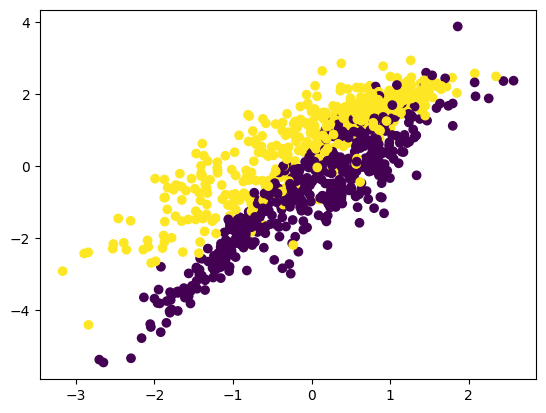

In [3]:
x,y = make_classification(n_classes=2,n_features=5,n_samples=1000,random_state=1)
plt.scatter(x[:,0],x[:,1],c=y)

The two classes overlap in this view. That is good for this lesson: a perfect model would
make every threshold look fine and the curve would teach us nothing.

In [4]:
X_train , X_test,Y_train, Y_test = train_test_split(x,y, test_size=0.2, random_state=1)

The split happens **before** anything is fitted. Every number after this point is measured on
the 200 test rows the model has never seen.

In [5]:
c1 = LogisticRegression()
c1.fit(X_train,Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

## 4. The model returns a probability, not a label

This is the step most people skip. `predict()` looks like the model's real output, but it is
not — it is `predict_proba()` with a `0.5` cut-off already applied for you.

In [6]:
proba = c1.predict_proba(X_test)   # two columns: P(class 0), P(class 1)
p1 = proba[:, 1]                   # keep the probability of the positive class

pd.DataFrame({
    "P(class 0)": proba[:8, 0].round(3),
    "P(class 1)": p1[:8].round(3),
    "predict() says": c1.predict(X_test)[:8],
    "true label": Y_test[:8],
})

,P(class 0),P(class 1),predict() says,true label
0,0.450,0.550,1,0
1,0.392,0.608,1,1
2,0.009,0.991,1,1
3,0.078,0.922,1,1
4,0.186,0.814,1,1
5,1.000,0.000,0,0
6,0.589,0.411,0,1
7,0.958,0.042,0,0


In [7]:
# predict() is nothing more than "probability >= 0.5"
print("predict() == (p1 >= 0.5) :", np.array_equal(c1.predict(X_test), (p1 >= 0.5).astype(int)))
print("accuracy at threshold 0.5:", round(c1.score(X_test, Y_test), 4))

predict() == (p1 >= 0.5) : True
accuracy at threshold 0.5: 0.815


`0.5` is a **default**, not a law. Nothing in the data chose it. The next cell shows what
happens when we move it.

## 5. What a threshold actually does

Below, each histogram shows the same 200 test rows sorted by their predicted probability:

- **blue** = rows that are really negative (`y = 0`),
- **red** = rows that are really positive (`y = 1`),
- the **black dashed line** is the threshold.

Everything to the **right** of the line is predicted positive. Everything to the **left** is
predicted negative.

Watch the two counts in each title as the line moves:

- move the line **left** → we catch more positives (**TPR up**) but raise more false alarms (**FPR up**),
- move the line **right** → fewer false alarms (**FPR down**) but we miss more positives (**TPR down**).

You cannot improve both at once. That trade is what the ROC curve draws.

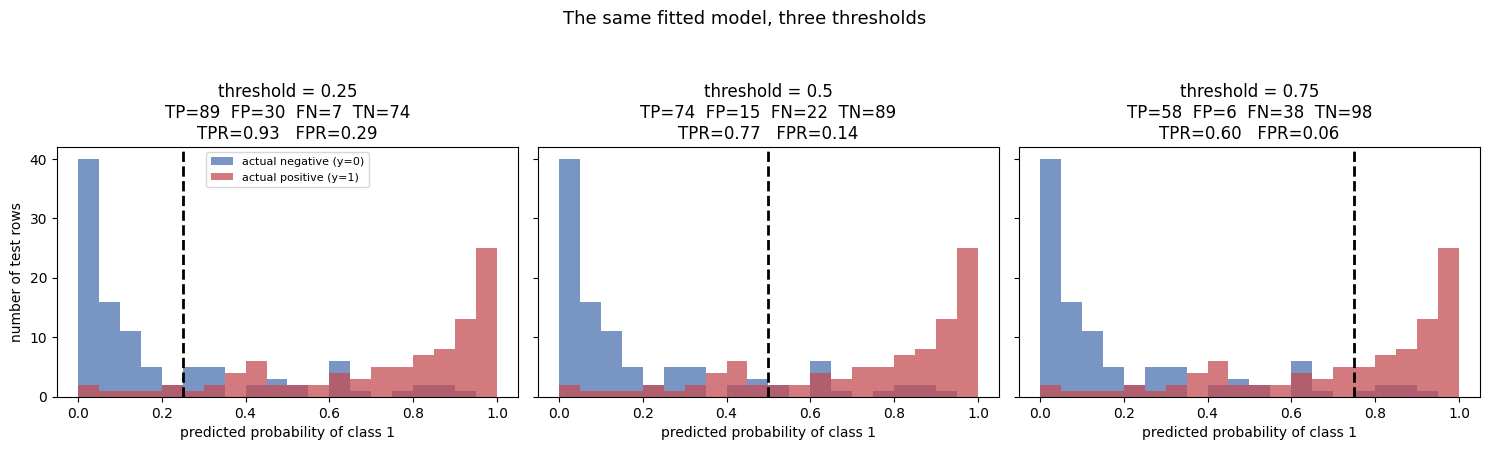

In [8]:
def counts_at(threshold):
    # returns TP, FN, FP, TN for one threshold, in the layout of the handwritten notes
    pred = (p1 >= threshold).astype(int)
    tp = int(((pred == 1) & (Y_test == 1)).sum())
    fn = int(((pred == 0) & (Y_test == 1)).sum())
    fp = int(((pred == 1) & (Y_test == 0)).sum())
    tn = int(((pred == 0) & (Y_test == 0)).sum())
    return tp, fn, fp, tn


fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)

for ax, t in zip(axes, [0.25, 0.50, 0.75]):
    ax.hist(p1[Y_test == 0], bins=20, range=(0, 1), alpha=0.75, color="#4C72B0", label="actual negative (y=0)")
    ax.hist(p1[Y_test == 1], bins=20, range=(0, 1), alpha=0.75, color="#C44E52", label="actual positive (y=1)")
    ax.axvline(t, color="black", linestyle="--", linewidth=2)

    tp, fn, fp, tn = counts_at(t)
    tpr, fpr = tp / (tp + fn), fp / (fp + tn)
    ax.set_title(f"threshold = {t}\nTP={tp}  FP={fp}  FN={fn}  TN={tn}\nTPR={tpr:.2f}   FPR={fpr:.2f}")
    ax.set_xlabel("predicted probability of class 1")

axes[0].set_ylabel("number of test rows")
axes[0].legend(loc="upper center", fontsize=8)
plt.suptitle("The same fitted model, three thresholds", y=1.06, fontsize=13)
plt.tight_layout()
plt.show()

### The confusion matrix at one threshold

Same four numbers, printed in the layout from your notes: rows are the truth, columns are the
prediction.

In [9]:
tp, fn, fp, tn = counts_at(0.5)

cm_my_layout = pd.DataFrame([[tp, fn], [fp, tn]],
                            index=["Actual Positive (AP)", "Actual Negative (AN)"],
                            columns=["Predicted Positive (PP)", "Predicted Negative (PN)"])
display(cm_my_layout)

print("Recall / TPR =", round(tp / (tp + fn), 3), "  <- of the real positives, how many we caught")
print("FPR          =", round(fp / (fp + tn), 3), "  <- of the real negatives, how many we alarmed on")
print("Precision    =", round(tp / (tp + fp), 3), "  <- of our positive calls, how many were right")
print("Accuracy     =", round((tp + tn) / (tp + tn + fp + fn), 3))

,Predicted Positive (PP),Predicted Negative (PN)
Actual Positive (AP),74,22
Actual Negative (AN),15,89


Recall / TPR = 0.771   <- of the real positives, how many we caught
FPR          = 0.144   <- of the real negatives, how many we alarmed on
Precision    = 0.831   <- of our positive calls, how many were right
Accuracy     = 0.815


> **Gotcha worth knowing:** `metrics.confusion_matrix` does **not** use the layout above. It
> sorts the labels, so for `0/1` data it prints
> $\begin{bmatrix} TN & FP \\ FN & TP \end{bmatrix}$ — the positive class ends up in the
> *bottom-right*, not the top-left. Same four numbers, different corners.

In [10]:
print("sklearn order  [[TN, FP], [FN, TP]]:")
print(metrics.confusion_matrix(Y_test, (p1 >= 0.5).astype(int)))
print("\nby hand        TP, FN, FP, TN =", counts_at(0.5))

sklearn order  [[TN, FP], [FN, TP]]:
[[89 15]
 [22 74]]

by hand        TP, FN, FP, TN = (74, 22, 15, 89)


## 6. Building the ROC curve by hand

The recipe is short:

```text
for every threshold from 1 down to 0:
    predict = probability >= threshold
    compute TPR and FPR
    plot the dot (FPR, TPR)
```

That is all a ROC curve is: **one dot per threshold**, joined up.

Two ends are fixed and worth checking against common sense:

- threshold `1.0` → we call nothing positive → `TPR = 0`, `FPR = 0` → bottom-left corner,
- threshold `0.0` → we call everything positive → `TPR = 1`, `FPR = 1` → top-right corner.

Every useful model lives between those two corners.

In [11]:
grid = np.linspace(1.0, 0.0, 101)

roc_by_hand = pd.DataFrame(
    [(t, *(lambda c: (c[0] / (c[0] + c[1]), c[2] / (c[2] + c[3])))(counts_at(t))) for t in grid],
    columns=["threshold", "TPR", "FPR"],
)

roc_by_hand.iloc[::20].round(3)   # every 20th row, so the two corners are visible

,threshold,TPR,FPR
0,1.0,0.000,0.000
20,0.8,0.552,0.048
40,0.6,0.729,0.125
60,0.4,0.854,0.192
80,0.2,0.948,0.308
100,0.0,1.000,1.000


### Does scikit-learn agree?

`metrics.roc_curve` does the same sweep, but it is smarter about the thresholds: it only uses
the values where the answer actually changes — the predicted probabilities themselves. That is
why it returns 54 thresholds instead of our 101 evenly spaced ones.

Its first threshold is `inf`, a placeholder that produces the `(0, 0)` corner. We skip it and
recompute the rest by hand.

In [12]:
fpr_sk, tpr_sk, th_sk = metrics.roc_curve(Y_test, p1)

hand = np.array([[c[0] / (c[0] + c[1]), c[2] / (c[2] + c[3])] for c in map(counts_at, th_sk[1:])])

print("thresholds returned by sklearn:", len(th_sk), " first value:", th_sk[0])
print("TPR matches by hand:", np.allclose(hand[:, 0], tpr_sk[1:]))
print("FPR matches by hand:", np.allclose(hand[:, 1], fpr_sk[1:]))

thresholds returned by sklearn: 54  first value: inf
TPR matches by hand: True
FPR matches by hand: True


### The picture

Now plot the dots. The dashed diagonal is the **coin flip**: a model with no information gets
TPR and FPR rising together, so it sits on that line.

- **up and to the left** is better — more catches for the same number of false alarms,
- the **top-left corner** `(0, 1)` is the perfect model: every positive caught, zero false alarms,
- a curve **below** the diagonal is worse than guessing (usually a flipped label).

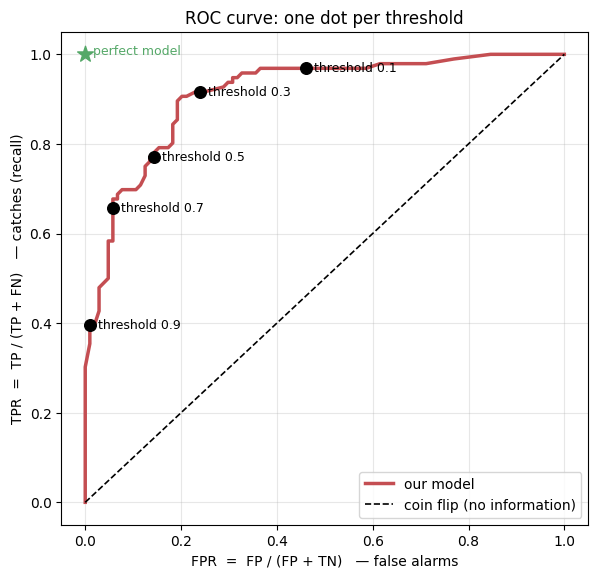

In [13]:
plt.figure(figsize=(6.8, 6.4))
plt.plot(roc_by_hand["FPR"], roc_by_hand["TPR"], color="#C44E52", linewidth=2.5, label="our model")
plt.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="coin flip (no information)")

for t in [0.9, 0.7, 0.5, 0.3, 0.1]:
    tp, fn, fp, tn = counts_at(t)
    x_, y_ = fp / (fp + tn), tp / (tp + fn)
    plt.scatter(x_, y_, s=70, color="black", zorder=5)
    plt.annotate(f"  threshold {t}", (x_, y_), fontsize=9, va="center")

plt.scatter([0], [1], s=140, marker="*", color="#55A868", zorder=6)
plt.annotate("  perfect model", (0, 1), fontsize=9, color="#55A868")

plt.xlabel("FPR  =  FP / (FP + TN)   — false alarms")
plt.ylabel("TPR  =  TP / (TP + FN)   — catches (recall)")
plt.title("ROC curve: one dot per threshold")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Read the dots in order. A **high** threshold sits bottom-left: the model is cautious, few
alarms, few catches. As the threshold drops we walk up and to the right: more catches, more
alarms. The curve *is* that walk.

## 7. AUC — one number for the whole curve

**AUC** is the **A**rea **U**nder the **C**urve. It is the area of the region below the ROC
line, so it is always between 0 and 1.

| AUC | Meaning |
|---|---|
| `1.0` | perfect separation |
| `0.9` | strong |
| `0.7` | usable |
| `0.5` | no better than a coin flip |
| `< 0.5` | worse than guessing — check for flipped labels |

The useful definition is not geometric at all:

> **AUC is the probability that a randomly chosen positive row gets a higher score than a
> randomly chosen negative row.**

That definition explains why AUC does not care about the threshold — it only cares about the
**ranking** of the scores. We can check it directly: compare every positive against every
negative and count the wins.

In [14]:
pos, neg = p1[Y_test == 1], p1[Y_test == 0]

wins = (pos[:, None] > neg[None, :]).mean() + 0.5 * (pos[:, None] == neg[None, :]).mean()

print(f"pairs compared      : {len(pos)} x {len(neg)} = {len(pos) * len(neg)}")
print(f"positive scored higher: {wins:.6f}")
print(f"metrics.roc_auc_score : {metrics.roc_auc_score(Y_test, p1):.6f}")
print("same number:", np.isclose(wins, metrics.roc_auc_score(Y_test, p1)))

pairs compared      : 96 x 104 = 9984
positive scored higher: 0.911558
metrics.roc_auc_score : 0.911558
same number: True


Two ways of computing, one answer. AUC really is *"how often does the model rank a true
positive above a true negative?"*

## 8. Why this matters: the accuracy trap

Now the point of the whole notebook. Make the classes imbalanced — 95% negative, 5% positive —
and compare a lazy model that always answers `0` with a real fitted model.

In [15]:
x_imb, y_imb = make_classification(n_classes=2, n_features=5, n_samples=2000,
                                   weights=[0.95, 0.05], random_state=1)
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(x_imb, y_imb, test_size=0.2,
                                              random_state=1, stratify=y_imb)

lazy_pred  = np.zeros_like(yi_te)                  # "nothing is ever positive"
lazy_score = np.zeros(len(yi_te), dtype=float)

real  = LogisticRegression(max_iter=1000).fit(Xi_tr, yi_tr)
real_p = real.predict_proba(Xi_te)[:, 1]

pd.DataFrame({
    "accuracy": [metrics.accuracy_score(yi_te, lazy_pred), metrics.accuracy_score(yi_te, real.predict(Xi_te))],
    "recall (TPR)": [metrics.recall_score(yi_te, lazy_pred, zero_division=0), metrics.recall_score(yi_te, real.predict(Xi_te))],
    "AUC": [metrics.roc_auc_score(yi_te, lazy_score), metrics.roc_auc_score(yi_te, real_p)],
}, index=["always predicts 0", "LogisticRegression"]).round(3)

,accuracy,recall (TPR),AUC
always predicts 0,0.948,0.000,0.500
LogisticRegression,0.980,0.667,0.968


The lazy model scores around **95% accuracy** and catches **zero** positives. Accuracy alone
cannot see that failure. **AUC** can: it lands on `0.5`, the coin-flip value, because the model
carries no information at all.

This is the reason we bother with ROC:

1. accuracy depends on the threshold, **AUC does not**,
2. accuracy depends on the class balance, **AUC does not**,
3. accuracy hides which mistake you are making, the **curve shows both sides**.

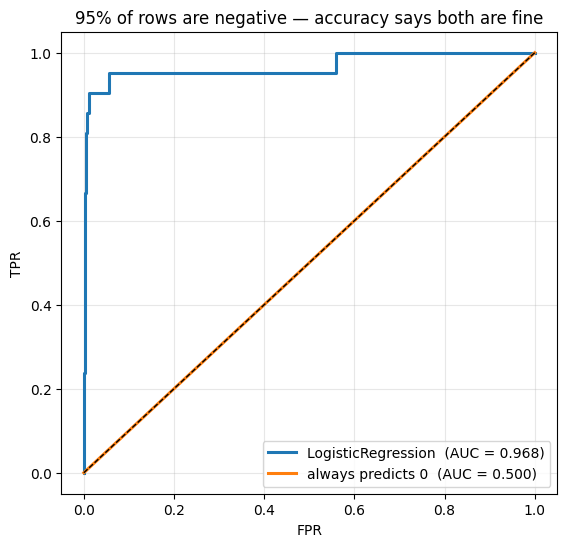

In [16]:
plt.figure(figsize=(6.4, 6))
for score, name in [(real_p, "LogisticRegression"), (lazy_score, "always predicts 0")]:
    f, t, _ = metrics.roc_curve(yi_te, score)
    plt.plot(f, t, linewidth=2.2, label=f"{name}  (AUC = {metrics.roc_auc_score(yi_te, score):.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("95% of rows are negative — accuracy says both are fine")
plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.show()

## 9. What good, average and useless curves look like

Same code, three datasets. `class_sep` controls how far apart the two classes sit, so it is a
dial for "how learnable is this problem".

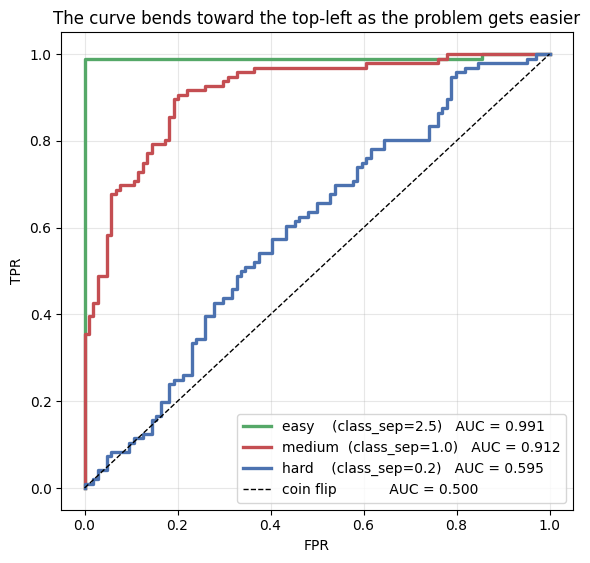

In [17]:
plt.figure(figsize=(6.6, 6.2))

for sep, colour, name in [(2.5, "#55A868", "easy    (class_sep=2.5)"),
                          (1.0, "#C44E52", "medium  (class_sep=1.0)"),
                          (0.2, "#4C72B0", "hard    (class_sep=0.2)")]:
    xs, ys = make_classification(n_classes=2, n_features=5, n_samples=1000,
                                 class_sep=sep, random_state=1)
    a_tr, a_te, b_tr, b_te = train_test_split(xs, ys, test_size=0.2, random_state=1)
    s = LogisticRegression(max_iter=1000).fit(a_tr, b_tr).predict_proba(a_te)[:, 1]
    f, t, _ = metrics.roc_curve(b_te, s)
    plt.plot(f, t, color=colour, linewidth=2.4,
             label=f"{name}   AUC = {metrics.roc_auc_score(b_te, s):.3f}")

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="coin flip            AUC = 0.500")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("The curve bends toward the top-left as the problem gets easier")
plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.show()

## 10. The error in this notebook: `metrics.plot_roc_curve`

Your last cell called `metrics.plot_roc_curve(c1, X_test, Y_test)` and raised:

```text
AttributeError: module 'sklearn.metrics' has no attribute 'plot_roc_curve'
```

Nothing is wrong with your logic. The **API changed**:

| scikit-learn version | Status |
|---|---|
| ≤ 1.0 | `metrics.plot_roc_curve(estimator, X, y)` worked |
| 1.0 | deprecated, with a warning |
| **1.2 and later** | **removed** — the attribute does not exist |

This environment runs **1.9.0**, so the function is long gone. scikit-learn replaced the whole
family of `plot_*` functions (`plot_roc_curve`, `plot_confusion_matrix`,
`plot_precision_recall_curve`) with **Display classes** that carry two constructors:

| Instead of | Use |
|---|---|
| `metrics.plot_roc_curve(model, X, y)` | `metrics.RocCurveDisplay.from_estimator(model, X, y)` |
| — (you only have scores) | `metrics.RocCurveDisplay.from_predictions(y_true, y_score)` |

The cell below is kept **on purpose**, wrapped so the notebook still runs top to bottom. The
error message is real output, not a comment.

In [18]:
# kept on purpose: this is the call that fails on scikit-learn >= 1.2
try:
    metrics.plot_roc_curve(c1,X_test,Y_test)
except AttributeError as e:
    print("AttributeError:", e)
    print("sklearn version:", __import__("sklearn").__version__)

AttributeError: module 'sklearn.metrics' has no attribute 'plot_roc_curve'
sklearn version: 1.9.0


### The fix

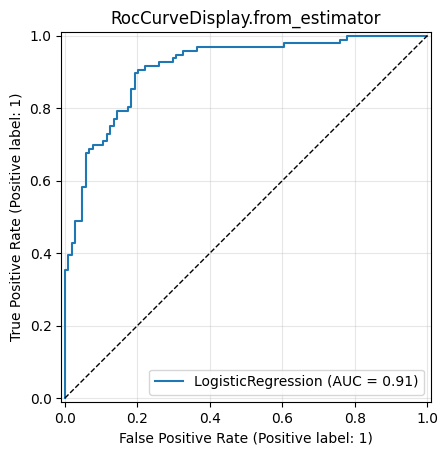

In [19]:
# 1. from the fitted model + test data  (direct replacement for plot_roc_curve)
metrics.RocCurveDisplay.from_estimator(c1, X_test, Y_test)
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.title("RocCurveDisplay.from_estimator")
plt.grid(alpha=0.3)
plt.show()

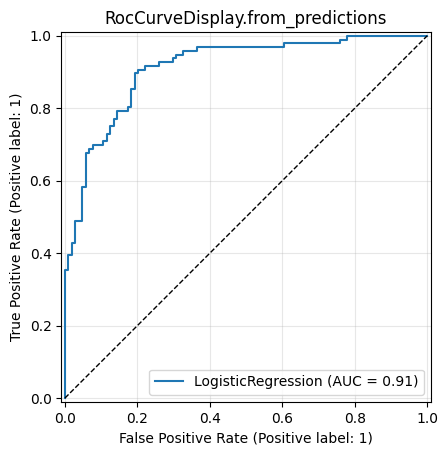

In [20]:
# 2. from scores you already have (works for any model, even one sklearn never saw)
metrics.RocCurveDisplay.from_predictions(Y_test, p1, name="LogisticRegression")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.title("RocCurveDisplay.from_predictions")
plt.grid(alpha=0.3)
plt.show()

Both draw the same curve as the one we built by hand in section 6, and the `AUC` printed in the
legend is the same number our pair-counting produced in section 7.

## 11. Choosing a threshold on purpose

The curve does not choose for you. **The cost of each mistake does.**

- Cancer screening: a missed case (**FN**) is far worse than an extra test (**FP**) → push the
  threshold **down**, accept more false alarms.
- Blocking a payment: a wrongly blocked customer (**FP**) is expensive → push the threshold
  **up**, accept a few misses.

When no business cost is given, a common neutral starting point is **Youden's J**: the point
that is furthest above the diagonal, `max(TPR - FPR)`.

In [21]:
j = tpr_sk - fpr_sk
best = j.argmax()
best_t = th_sk[best]

print(f"best threshold by Youden's J : {best_t:.3f}   (not 0.5)")
print(f"   TPR {tpr_sk[best]:.3f}   FPR {fpr_sk[best]:.3f}")

rows = {}
for label, t in [("threshold 0.5 (default)", 0.5), (f"threshold {best_t:.3f} (Youden)", best_t)]:
    tp, fn, fp, tn = counts_at(t)
    rows[label] = {"TP": tp, "FN (missed)": fn, "FP (false alarm)": fp, "TN": tn,
                   "recall": round(tp / (tp + fn), 3),
                   "precision": round(tp / (tp + fp), 3),
                   "accuracy": round((tp + tn) / 200, 3)}

pd.DataFrame(rows).T

best threshold by Youden's J : 0.346   (not 0.5)
   TPR 0.906   FPR 0.202


,TP,FN (missed),FP (false alarm),TN,recall,precision,accuracy
threshold 0.5 (default),74.0,22.0,15.0,89.0,0.771,0.831,0.815
threshold 0.346 (Youden),87.0,9.0,21.0,83.0,0.906,0.806,0.850


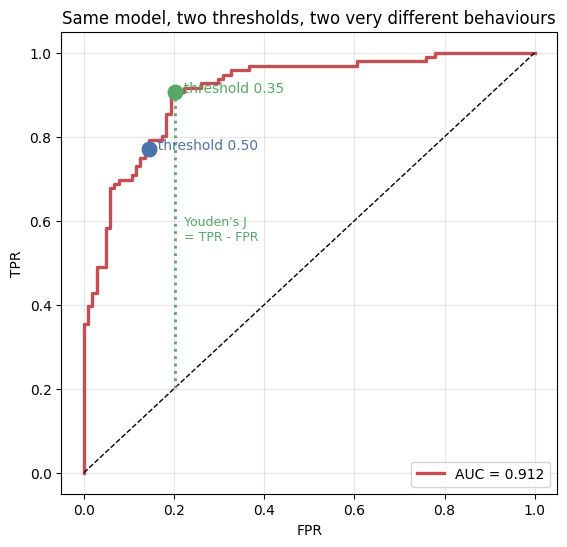

In [22]:
plt.figure(figsize=(6.4, 6))
plt.plot(fpr_sk, tpr_sk, color="#C44E52", linewidth=2.4, label=f"AUC = {metrics.roc_auc_score(Y_test, p1):.3f}")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)

for idx, t, colour in [(best, best_t, "#55A868"), (np.abs(th_sk - 0.5).argmin(), 0.5, "#4C72B0")]:
    plt.scatter(fpr_sk[idx], tpr_sk[idx], s=110, color=colour, zorder=5)
    plt.annotate(f"  threshold {t:.2f}", (fpr_sk[idx], tpr_sk[idx]), color=colour, fontsize=10)

plt.vlines(fpr_sk[best], fpr_sk[best], tpr_sk[best], color="#55A868", linestyle=":", linewidth=2)
plt.text(fpr_sk[best] + 0.02, (fpr_sk[best] + tpr_sk[best]) / 2, "Youden's J\n= TPR - FPR",
         color="#55A868", fontsize=9)

plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("Same model, two thresholds, two very different behaviours")
plt.legend(loc="lower right"); plt.grid(alpha=0.3)
plt.show()

Dropping the threshold from `0.5` to about `0.35` catches many more positives and misses far
fewer, and it costs a handful of extra false alarms. Which trade is right is a **product**
decision, not a modelling one.

## 12. Where this shows up in real systems

Think of a fraud-scoring or spam-scoring service you would build in Spring Boot:

```text
request -> features -> model.predict_proba() -> score (0..1) -> threshold -> decision
```

- The **model** produces the score. The **threshold** is application configuration, not model
  weights. Changing it is a config change, not a retrain — you can move it per customer, per
  region, or per time of day.
- **AUC** is the right metric for *"is the new model better than the old one?"*, because it
  compares the ranking quality without freezing a threshold.
- **TPR / FPR at the chosen threshold** is the right metric for the SLA conversation, because
  that is what the business actually feels: alarms raised and cases missed.
- Log the raw score, not just the decision. If you only store the yes/no answer, you can never
  re-draw this curve or re-tune the threshold from production data.

## Common mistakes

1. **Treating `0.5` as part of the model.** It is a default applied after the model, and it is
   rarely the best choice on imbalanced data.
2. **Passing labels to `roc_curve` instead of scores.** `metrics.roc_curve(y, model.predict(X))`
   gives you a curve with a single bend and a meaningless AUC. It needs `predict_proba(X)[:, 1]`
   or `decision_function(X)`.
3. **Taking column 0 of `predict_proba`.** Column 0 is `P(class 0)`. Using it flips the curve
   below the diagonal and gives `AUC = 1 - real AUC`.
4. **Trusting AUC on very imbalanced data.** AUC ignores class balance, which is its strength
   for comparing models and its weakness for judging usefulness. With 1% positives, use a
   **precision-recall curve** alongside it.
5. **Reading the ROC of training data.** Like every metric, it must be measured on rows the
   model has not seen.

## Interview view

- *What does the ROC curve plot?* TPR against FPR, one point for every possible threshold.
- *What is AUC in words?* The probability that a random positive is scored above a random
  negative. `0.5` is a coin flip.
- *Why not accuracy?* It depends on the threshold and the class balance, and it hides which of
  the two mistakes you are making.
- *When does AUC mislead?* On heavy imbalance, where a good AUC can still mean poor precision.
- *ROC or precision-recall?* ROC when both classes matter; PR when the positive class is rare
  and false alarms are expensive.

## Key takeaway

**If you remember only one thing:** a classifier outputs a **score**, not a decision. The
threshold turns the score into a decision, and the ROC curve is simply that same model drawn at
**every** threshold — TPR up, FPR across.

`AUC` collapses the curve into one number that means *"how often does this model rank a true
positive above a true negative?"* — `1.0` is perfect, `0.5` is a coin flip. It judges the
**ranking**; you still have to choose the **threshold** yourself, and that choice belongs to
whoever pays for a false alarm or a missed case.

And on scikit-learn ≥ 1.2, `metrics.plot_roc_curve` no longer exists — use
`metrics.RocCurveDisplay.from_estimator(model, X, y)`.